# Module project: Computational Chemistry with Python

### Group L : Taïs Thomas, Marouchka Heck, Marie-Caroline Bilocq

## PART A - Data structures and functions

### 1. Load the "periodic_table.csv" data file using pandas

We first load the periodic data table using pandas and preview the first rows to check its structure and column names, which will be useful for Question 2 when we need to call the columns for the dictionnary.

In [1]:
import pandas as pd

periodic_table = pd.read_csv("periodic_table.csv")
periodic_table.head(5)

,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,OxidationStates,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered
0,1,H,Hydrogen,1.008000,FFFFFF,1s1,2.20,120.0,13.598,0.754,"+1, -1",Gas,13.81,20.28,0.000090,Nonmetal,1766
1,2,He,Helium,4.002600,D9FFFF,1s2,NaN,140.0,24.587,NaN,0,Gas,0.95,4.22,0.000179,Noble gas,1868
2,3,Li,Lithium,7.000000,CC80FF,[He]2s1,0.98,182.0,5.392,0.618,+1,Solid,453.65,1615.00,0.534000,Alkali metal,1817
3,4,Be,Beryllium,9.012183,C2FF00,[He]2s2,1.57,153.0,9.323,NaN,+2,Solid,1560.00,2744.00,1.850000,Alkaline earth metal,1798
4,5,B,Boron,10.810000,FFB5B5,[He]2s2 2p1,2.04,192.0,8.298,0.277,+3,Solid,2348.00,4273.00,2.370000,Metalloid,1808


### 2. Create a python dictionnary where the keys are elements symbol and the values are atomic masses.

In [2]:
atomic_masses = dict(zip(periodic_table["Symbol"], periodic_table["AtomicMass"]))

### 3. Write a function that takes chemical formulas like “H₂O” and “C₆H₁₂O₆” and return their molecular mass.

I'll iterate through every character in the formula and check whether it's a letter or a number. Then I will assign the corresponding atomic mass if it is a letter and if it is a number I will multiply the previous element atomic mass by that number.

In [3]:

def molecular_mass(chemical_formula):
    mass = 0
    
    for character in chemical_formula:
        if character.isalpha():
            element = character
            mass += atomic_masses[element]
        elif character.isdigit():
            number = int(character)
            mass += atomic_masses[element] * (int(character) - 1)

    return mass

print(molecular_mass("H2O"))
print(molecular_mass("C6H12O6"))

18.015
170.07599999999996


I first tried to read the formula character by character and separate the letters from the numbers. This works for a simple formula like $\mathrm{H_2O}$, but it does not work correctly for $\mathrm{C_6H_{12}O_6}$, because the 12 is read as 1 and 2 separately instead of as the number 12. Another problem would appear with elements that have two-letter symbols, such as Ca or Cl, since the code would read each letter as a different element. To solve these problems, I used a regular expression `re.findall` to identify the complete element symbol together with the number that follows it. If there is no number after an element, the number of atoms is set to 1. This allows the molecular mass to be calculated correctly by multiplying each atomic mass by the corresponding number of atoms.

#### Corrected version of question 3

In [4]:
import re

def molecular_mass(chemical_formula):
    mass = 0
    elements = re.findall(r"([A-Z][a-z]?)(\d*)", chemical_formula)

    for element, number in elements:
        if number == "":
            number = 1
        else:
            number = int(number)

        mass += atomic_masses[element] * number

    return mass

print(molecular_mass("H2O"))
print(molecular_mass("C6H12O6"))

18.015
180.156


### 4. Extend the molecular mass calculator to handle parentheses in formulas (e.g., “Ca(OH)₂”).

To extend the function from Question 3, I redefine `molecular_mass()` to first check for parentheses. If there are no parentheses, the calculation remains the same as in Question 3.

In [5]:
def molecular_mass(chemical_formula):
    mass = 0

    if "(" in chemical_formula:
        start = chemical_formula.find("(")
        end = chemical_formula.find(")")

        group = chemical_formula[start + 1:end]

        position = end + 1
        number = ""

        while position < len(chemical_formula) and chemical_formula[position].isdigit():
            number += chemical_formula[position]
            position += 1

        if number == "":
            number = 1
        else:
            number = int(number)

        group_mass = molecular_mass(group)

        remaining_formula = chemical_formula[:start] + chemical_formula[position:]

        return molecular_mass(remaining_formula) + group_mass * number

    elements = re.findall(r"([A-Z][a-z]?)(\d*)", chemical_formula)

    for element, number in elements:
        if number == "":
            number = 1
        else:
            number = int(number)

        mass += atomic_masses[element] * number

    return mass

print(molecular_mass("Ca(OH)2"))

74.094


To handle parentheses, I first identify the part of the formula inside the parentheses and the number that follows it. I then use recursion by calling `molecular_mass()` again on the group inside the parentheses. The mass of this group is multiplied by the number after the parentheses and added to the mass of the remaining formula. If there are no parentheses, the function uses the same method as in Question 3.

### 5. Extend the molecular mass calculator so it can handle coordinated (hydration) water (e.g. “CuSO4.5H2O”) (5 points)

To extend the function from Question 4, I redefine `molecular_mass()` to first check for hydration water. If there is no hydration water, the calculation remains the same as in Question 4.

In [6]:
def molecular_mass(chemical_formula):
    mass = 0

    if "." in chemical_formula:
        parts = chemical_formula.split(".")

        compound = parts[0]
        hydrate = parts[1]

        match = re.match(r"(\d+)(.*)", hydrate)
        number = int(match.group(1))
        water = match.group(2)

        return molecular_mass(compound) + number * molecular_mass(water)

    if "(" in chemical_formula:
        start = chemical_formula.find("(")
        end = chemical_formula.find(")")

        group = chemical_formula[start + 1:end]

        position = end + 1
        number = ""

        while position < len(chemical_formula) and chemical_formula[position].isdigit():
            number += chemical_formula[position]
            position += 1

        if number == "":
            number = 1
        else:
            number = int(number)

        group_mass = molecular_mass(group)

        remaining_formula = chemical_formula[:start] + chemical_formula[position:]

        return molecular_mass(remaining_formula) + group_mass * number

    elements = re.findall(r"([A-Z][a-z]?)(\d*)", chemical_formula)

    for element, number in elements:
        if number == "":
            number = 1
        else:
            number = int(number)

        mass += atomic_masses[element] * number

    return mass

print(molecular_mass("CuSO4.5H2O"))

249.69100000000003


To extend the function to hydration water, I first check if the formula contains a ".". If it does, I split the formula into the main compound and the hydrate part. I then separate the coefficient from the water formula and calculate the molecular mass of both parts using the `molecular_mass()` function. Finally, the mass of the water is multiplied by its coefficient and added to the mass of the main compound.

## PART B - Stoichiometry and reaction balancing

### 1. Reaction Balancer Function

A chemical equation is balanced when the number of atoms on the reactant side equals the number on the product side for every element. In order to do so, the goal of the following function is to take a chemical formula as a string and determine how many atoms of each elements are present in that formula.

In [7]:
import re
import numpy as np
from fractions import Fraction
from math import gcd
from functools import reduce

def atom_counts_first_attempt(formula):
    counts = {}
    i = 0
    while i < len(formula):
        el = formula[i]
        i += 1
        num = ''
        while i < len(formula) and formula[i].isdigit():
            num += formula[i]
            i += 1
        n = int(num) if num else 1
        counts[el] = counts.get(el, 0) + n
    return counts

print(atom_counts_first_attempt("H2O"))
print(atom_counts_first_attempt("NaCl"))

{'H': 2, 'O': 1}
{'N': 1, 'a': 1, 'C': 1, 'l': 1}


This function reads every single character as its own symbol. This works well with molecules made of one letter atoms, as we can see from the first example with $H_2O$. However,  it breaks down as soon as a two-letter symbol appears. In the NaCl example above, the Na element is broke down into "N" and "a". 
In order to correct this problem, a pattern is used in the following function to explicitly match an optional lowercase letter following the uppercase one, so a symbol like "Na" or "Cl" is captured as a single unit instead of being split character by character.

In [8]:
def get_atom_counts(formula):
    pattern = r'([A-Z][a-z]?)(\d*)'
    counts = {}
    for element, num in re.findall(pattern, formula):
        if element == '':
            continue
        n = int(num) if num else 1
        counts[element] = counts.get(element, 0) + n
    return counts

get_atom_counts("H2O"), get_atom_counts("NaCl")

({'H': 2, 'O': 1}, {'Na': 1, 'Cl': 1})

Then, the function `balance_reaction` actually balances the equation and combines the reactants and the products to determine how many atoms of each elements are present in every molecule. The matrix A is constructed from these values, with the columns being each a molecule and the rows an element. Reactants have positive element counts while products have negative ones. 
The function then finds a set of coefficient that makes the total number of every element equal on both sides of the equation so that a balanced equation corresponds to the condition :

$$
A\mathbf{x}=0
$$

where $\mathbf{x}$ is the vector containing the unknown coefficients of the molecules.

Then the Singular Value Decomposition method is used to find a vector in the null space of (A). This gives the ratios between the coefficients needed to balance the reaction. The values are then converted into the smallest whole numbers so they can be used as the coefficients in the balanced equation with the function `make_whole_numbers`. 

In [9]:
def make_whole_numbers(null_vec, max_denominator=20):
    nonzero = [abs(v) for v in null_vec if abs(v) > 1e-8]
    scaled = null_vec / min(nonzero)
    fracs = [Fraction(v).limit_denominator(max_denominator) for v in scaled]
    denominators = [f.denominator for f in fracs]
    lcm = reduce(lambda a, b: a * b // gcd(a, b), denominators, 1)
    ints = [int(f * lcm) for f in fracs]

    if any(v < 0 for v in ints):
        ints = [-v for v in ints]
    g = reduce(gcd, [abs(v) for v in ints])
    ints = [v // g for v in ints]
    return ints
    
def balance_reaction(reactants, products):
    species = reactants + products
    parsed = [get_atom_counts(f) for f in species]
    elements = sorted({el for comp in parsed for el in comp})

    A = np.zeros((len(elements), len(species)))
    for j, comp in enumerate(parsed):
        sign = 1 if j < len(reactants) else -1
        for i, el in enumerate(elements):
            A[i, j] = sign * comp.get(el, 0)

    U, S, Vt = np.linalg.svd(A)
    null_vec = Vt[-1] if len(S) < Vt.shape[0] else Vt[np.argmin(S)]

    return make_whole_numbers(null_vec)

print(balance_reaction(["H2", "O2"], ["H2O"]))

[2, 1, 2]


As an example, the numbers printed above are the stoichiometric coefficients for $H_2$, $O_2$, and $H_2O$ respectively. They are the smallest positive integers that balance the equation 
$$
2H_2 + O_2 \rightarrow 2H_2O
$$
Then the function is tested for 3 chemical equations to make sure that it works correctly:

In [10]:
tests = [
    (["H2", "O2"], ["H2O"]),
    (["Na", "Cl2"], ["NaCl"]),
    (["N2", "H2"], ["NH3"]),
]

results = []
for reactants, products in tests:
    coeffs = balance_reaction(reactants, products)
    r_coeffs, p_coeffs = coeffs[:len(reactants)], coeffs[len(reactants):]
    eq = " + ".join(f"{c}{f}" for c, f in zip(r_coeffs, reactants))
    eq += " -> " + " + ".join(f"{c}{f}" for c, f in zip(p_coeffs, products))
    print(eq)
    results.append((reactants, products, r_coeffs, p_coeffs))

2H2 + 1O2 -> 2H2O
2Na + 1Cl2 -> 2NaCl
1N2 + 3H2 -> 2NH3


### 2. Mass Conservation Check

According to the law of conservation of mass, the total mass of the reactants must be equal to the total mass of the products in a chemical reaction. In order to check that the equation has been correctly balanced, the total mass of the reactants and products can be calculated and compared using the coefficients found in question 1. 


The `is_mass_conserved` function checks if the total mass of the reactants is equal to the total mass of the products. In order to achieve that, it uses the `molecular_mass` function from Part A to find the mass of each molecule and multiplies it by its coefficient. 
Then, the masses are summed to obtain the total mass on each side and compare the two. The function prints both masses and returns True if the masses are equal and False otherwise.

In [11]:
def is_mass_conserved(reactants_coeffs, products_coeffs):

    reactant_mass = sum(coeff * molecular_mass(formula)
                         for formula, coeff in reactants_coeffs.items())
    product_mass = sum(coeff * molecular_mass(formula)
                        for formula, coeff in products_coeffs.items())

    balanced = np.isclose(reactant_mass, product_mass, rtol=1e-6)
    print(f"Total reactant mass: {reactant_mass:.4f} g/mol")
    print(f"Total product mass:  {product_mass:.4f} g/mol")
    print("Mass is conserved." if balanced else "Mass is not conserved.")
    return balanced

The function is then tested with the same reactions as before using the `balance_reaction` function from question 1.

In [12]:
for reactants, products in tests:
    coeffs = balance_reaction(reactants, products)
    r_coeffs = dict(zip(reactants, coeffs[:len(reactants)]))
    p_coeffs = dict(zip(products, coeffs[len(reactants):]))

    eq = " + ".join(f"{c}{f}" for f, c in r_coeffs.items())
    eq += " -> " + " + ".join(f"{c}{f}" for f, c in p_coeffs.items())
    print(eq)
    is_mass_conserved(r_coeffs, p_coeffs)
    print()

2H2 + 1O2 -> 2H2O
Total reactant mass: 36.0300 g/mol
Total product mass:  36.0300 g/mol
Mass is conserved.

2Na + 1Cl2 -> 2NaCl
Total reactant mass: 116.8795 g/mol
Total product mass:  116.8795 g/mol
Mass is conserved.

1N2 + 3H2 -> 2NH3
Total reactant mass: 34.0620 g/mol
Total product mass:  34.0620 g/mol
Mass is conserved.



## PART C - Simulation / Modeling

In [13]:
import numpy as np
import matplotlib.pyplot as plt

### *1. Monte Carlo π estimation*

**Write the estimate_pi(N) function**

A Monte Carlo simulation is a technique that uses repeated random sampling to obtain numerical results. It is very useful when calculating a very difficult and complex mathematical answer, like π for example. In the following cell, a function is created where N random points are uniformly placed inside a 2x2 square where the center is at the origin. The number of these points which fall into the unit circle of radius one with the center at the origin is determined. Using this, π can be determined by realizing that the ratio $ \frac{\text{area of circle}}{\text{area of square}} $ ($ \frac{\text{π}}{\text{4}} $) equals the ratio $ \frac{\text{points inside the circle}}{\text{total points}} $. Therefore, π is estimated as $ \pi \approx 4 \times \frac{\text{points inside circle}}{\text{total points}} $.

In [17]:
def estimate_pi(N):
    x = np.random.uniform(-1, 1, N)
    y = np.random.uniform(-1, 1, N)
    
    in_circle = (x**2 + y**2) <= 1
    
    points_in_circle = np.sum(in_circle)
    
    pi_estimation = 4 * points_in_circle / N
    
    return pi_estimation

We can now test this function by taking a random N and computing the π estimation.

In [18]:
N = 10000

pi_estimation = estimate_pi(N)

print("Estimated value of pi:", pi_estimation)
print("Actual value of pi:", np.pi)

Estimated value of pi: 3.1432
Actual value of pi: 3.141592653589793


As can be observed, the estimation of π is close to its actual value. If the function which determines the position of each point is rerun, the estimation will be different, although it will remain close to the correct value because of the randomness of each position. It can be noticed that the bigger the number of random points N, the more accurate the π value will be. Indeed, small samples give averages over a handful of random points, so a few unlucky draws can affect the ratio significantly. As N grows, the law of large numbers kicks in and the proportion of points inside the circle converges to the true probability π/4, making the estimate more stable and accurate. This is explicited in the following plot.

**Plot the convergence of your estimate versus N to visualize accuracy improvement**

This part aims to make the statement about small and bigger samples made previously more explicit. The plot helps visualize that the use of a large number of random points N will always give a more accurate result.

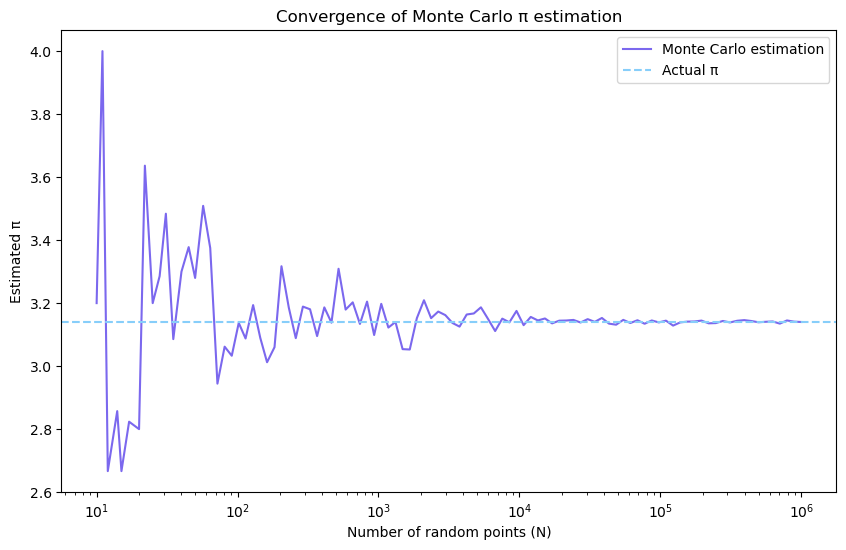

In [19]:
N_values = np.logspace(1, 6, 100, dtype=int)

pi_estimates = []

for N in N_values:
    pi_estimates.append(estimate_pi(N))

plt.figure(figsize=(10, 6))

plt.plot(N_values, pi_estimates, label="Monte Carlo estimation", color = 'mediumslateblue')
plt.axhline(np.pi, linestyle="--", label="Actual π", color = 'lightskyblue')

plt.xscale("log")
plt.xlabel("Number of random points (N)")
plt.ylabel("Estimated π")
plt.title("Convergence of Monte Carlo π estimation")
plt.legend()

plt.show()

What this demonstrates is that smaller numbers of N offer a less trustworhty estimation of π whereas larger numbers of N give estimations which converge towards the actual value of π. This demonstrates the accuracy improvemet offered by the increasing number od random points N.

### 2. *Chemistry-inspired Monte Carlo*

This second part aims to use the Monte Carlo method in another context. Now that its principle has been understood, it can be applied to a chemistry related problem, which is more interesting in this course. This exercise considers the idea that in chemistry, not every collision between molecules causes a reaction. A reaction only happens if the colliding molecules have enough kinetic energy to overcome the activation energy, which is the energy barrier that must be crossed for bonds to break and reform. In any real sample of gas or liquid, molecules have a whole distribution of energies, governed by the Maxwell-Boltzmann distribution in reality although it is simplified in this assignment as a uniform or normal distribution. This next function simulates this concept.

In [20]:
def simulate_collisions(M, threshold_energy, max_energy=100):
    
    energies = np.random.uniform(0, max_energy, M)
    
    successful_collisions = energies >= threshold_energy
    
    number_successful = np.sum(successful_collisions)
    
    reaction_probability = number_successful / M
    
    return energies, number_successful, reaction_probability

In order to make the function more visual, a range of energies between 0 and 100 was chosen to perform the estimation. We can now run the simulation, using 10 000 collisions and a threshold energy of 65 energy units. The high number of collisions was chosen according to the explanation made earlier about how larger samples give more accurate results.

In [21]:
M = 10000
threshold_energy = 65

energies, number_successful, reaction_probability = simulate_collisions(M, threshold_energy)

print("Total number of collisions:", M)
print("Threshold energy:", threshold_energy)
print("Number of collisions above threshold:", number_successful)
print("Estimated reaction probability:", reaction_probability)

Total number of collisions: 10000
Threshold energy: 65
Number of collisions above threshold: 3578
Estimated reaction probability: 0.3578


Because we're using a uniform distribution from 0 to 100, we expect approximately 35% of collisions to have an energy of 65 or greater, which is the case here.